# NBA Player Injury Risk Profiling (Player-Week Dynamic Model)

In [84]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib

# Step 1: Load and Clean Game Statistics

In [85]:
game_stats = pd.read_csv('Cleaned Data/Finished/PlayerStatistics.csv', low_memory=False)
game_stats['gameDate'] = pd.to_datetime(game_stats['gameDate'], errors='coerce')

# Filter to seasons 2010–2020 only
game_stats = game_stats[
    (game_stats['gameDate'].dt.year >= 2010) &
    (game_stats['gameDate'].dt.year <= 2020)
]

game_stats.head()


,firstName,lastName,personId,gameId,gameDate,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
175648,Chris,Paul,101108,22000068,2020-12-31 21:00:00,Phoenix,Suns,Utah,Jazz,Regular Season,...,0.5,1.0,1.0,1.000,3.0,1.0,4.0,2.0,3.0,12.0
175649,Mike,Conley,201144,22000068,2020-12-31 21:00:00,Utah,Jazz,Phoenix,Suns,Regular Season,...,0.5,2.0,2.0,1.000,5.0,0.0,5.0,2.0,2.0,-13.0
175650,Derrick,Favors,202324,22000068,2020-12-31 21:00:00,Utah,Jazz,Phoenix,Suns,Regular Season,...,0.0,3.0,2.0,0.667,2.0,3.0,5.0,0.0,0.0,-2.0
175651,Bojan,Bogdanovic,202711,22000068,2020-12-31 21:00:00,Utah,Jazz,Phoenix,Suns,Regular Season,...,0.0,4.0,3.0,0.750,1.0,0.0,1.0,0.0,3.0,-5.0
175652,E'Twaun,Moore,202734,22000068,2020-12-31 21:00:00,Phoenix,Suns,Utah,Jazz,Regular Season,...,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0


# Step 2: Build Dynamic Player-Week Dataset

In [86]:
def infer_season(date):
    year = date.year
    if date.month >= 9:
        return f"{year}-{year+1}"
    else:
        return f"{year-1}-{year}"

# Create season column
game_stats['season'] = game_stats['gameDate'].apply(infer_season)
game_stats = game_stats.sort_values(['personId', 'gameDate']).reset_index(drop=True)

player_week_snapshots = []
seasons = game_stats['season'].unique()

for season in seasons:
    season_games = game_stats[game_stats['season'] == season]

    min_date = season_games['gameDate'].min()
    max_date = season_games['gameDate'].max()

    weekly_cutoffs = pd.date_range(start=min_date, end=max_date, freq='W-MON')

    for cutoff_date in weekly_cutoffs:
        games_until_now = season_games[season_games['gameDate'] <= cutoff_date]

        if games_until_now.empty:
            continue

        summary = games_until_now.groupby('personId').agg({
            'firstName': 'first',
            'lastName': 'first',
            'numMinutes': ['count', 'mean'],
            'points': 'mean',
            'assists': 'mean',
            'reboundsTotal': 'mean'
        }).reset_index()

        summary.columns = [
            'personId', 'firstName', 'lastName',
            'games_played', 'avg_minutes',
            'avg_points', 'avg_assists', 'avg_rebounds'
        ]

        rolling5 = games_until_now.groupby('personId').apply(
            lambda df: df.tail(5).agg({
                'numMinutes': 'mean',
                'points': 'mean'
            })
        ).reset_index()

        rolling5.columns = ['personId', 'rolling5_minutes', 'rolling5_points']

        games_until_now['days_since_last_game'] = games_until_now.groupby('personId')['gameDate'].diff().dt.days
        games_until_now['back_to_back_flag'] = (games_until_now['days_since_last_game'] <= 1).astype(int)
        b2b = games_until_now.groupby('personId')['back_to_back_flag'].sum().reset_index()
        b2b.columns = ['personId', 'back_to_back_games']

        merged = summary.merge(rolling5, on='personId', how='left').merge(b2b, on='personId', how='left')
        merged['season'] = season
        merged['cutoff_date'] = cutoff_date

        player_week_snapshots.append(merged)

player_week_data = pd.concat(player_week_snapshots, ignore_index=True)
player_week_data.head()


/var/folders/xx/yvjw0z0x5qs5dfnqdw9cnglh0000gn/T/ipykernel_51407/3310215038.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolling5 = games_until_now.groupby('personId').apply(
/var/folders/xx/yvjw0z0x5qs5dfnqdw9cnglh0000gn/T/ipykernel_51407/3310215038.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  games_until_now['days_since_last_game'] = games_until_now.groupby('personId')['gameDate'].diff().dt.days
/var/folders/xx/yvjw0z0x5qs5dfnqdw9cnglh0000

,personId,firstName,lastName,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,rolling5_minutes,rolling5_points,back_to_back_games,season,cutoff_date
0,689,Theo,Ratliff,1,15.0,4.0,0.0,4.0,15.0,4.0,0,2010-2011,2010-10-04 15:00:00
1,965,Derek,Fisher,1,15.0,12.0,2.0,2.0,15.0,12.0,0,2010-2011,2010-10-04 15:00:00
2,977,Kobe,Bryant,1,6.0,0.0,2.0,1.0,6.0,0.0,0,2010-2011,2010-10-04 15:00:00
3,1885,Lamar,Odom,1,27.0,17.0,1.0,6.0,27.0,17.0,0,2010-2011,2010-10-04 15:00:00
4,1897,Metta,World Peace,1,17.0,3.0,2.0,1.0,17.0,3.0,0,2010-2011,2010-10-04 15:00:00


# Step 3: Standardize Features for Clustering and Modeling

In [87]:
# Load injuries
injuries = pd.read_csv('Cleaned Data/Finished/injury_locations_categorized.csv')
injuries['Date'] = pd.to_datetime(injuries['Date'], errors='coerce')
injuries['full_name'] = injuries['Relinquished']

player_week_data['full_name'] = player_week_data['firstName'] + ' ' + player_week_data['lastName']

injury_counts_dynamic = []

injury_dates_lookup = injuries.groupby('full_name')['Date'].apply(list).to_dict()

# Loop over each player-week snapshot
for idx, row in player_week_data.iterrows():
    full_name = row['full_name']
    cutoff_date = row['cutoff_date']

    # Get all recorded injury dates for that player
    player_injuries = injury_dates_lookup.get(full_name, [])

    # Count how many injuries happened BEFORE cutoff date
    past_injuries = sum(date <= cutoff_date for date in player_injuries)

    injury_counts_dynamic.append(past_injuries)

player_week_data['injury_count'] = injury_counts_dynamic
player_week_data[['firstName', 'lastName', 'cutoff_date', 'injury_count']].head()


,firstName,lastName,cutoff_date,injury_count
0,Theo,Ratliff,2010-10-04 15:00:00,0
1,Derek,Fisher,2010-10-04 15:00:00,0
2,Kobe,Bryant,2010-10-04 15:00:00,0
3,Lamar,Odom,2010-10-04 15:00:00,0
4,Metta,World Peace,2010-10-04 15:00:00,0


In [88]:
player_week_data.to_csv('Cleaned Data/Finished/player_week_data_final.csv', index=False)


In [89]:
# Reload from saved CSV
data = pd.read_csv('Cleaned Data/Finished/player_week_data_final.csv', low_memory=False)
data['cutoff_date'] = pd.to_datetime(data['cutoff_date'], errors='coerce')

data.head()

,personId,firstName,lastName,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,rolling5_minutes,rolling5_points,back_to_back_games,season,cutoff_date,full_name,injury_count
0,689,Theo,Ratliff,1,15.0,4.0,0.0,4.0,15.0,4.0,0,2010-2011,2010-10-04 15:00:00,Theo Ratliff,0
1,965,Derek,Fisher,1,15.0,12.0,2.0,2.0,15.0,12.0,0,2010-2011,2010-10-04 15:00:00,Derek Fisher,0
2,977,Kobe,Bryant,1,6.0,0.0,2.0,1.0,6.0,0.0,0,2010-2011,2010-10-04 15:00:00,Kobe Bryant,0
3,1885,Lamar,Odom,1,27.0,17.0,1.0,6.0,27.0,17.0,0,2010-2011,2010-10-04 15:00:00,Lamar Odom,0
4,1897,Metta,World Peace,1,17.0,3.0,2.0,1.0,17.0,3.0,0,2010-2011,2010-10-04 15:00:00,Metta World Peace,0


In [90]:
# Select features for modeling
feature_cols = [
    'games_played',
    'avg_minutes',
    'avg_points',
    'avg_assists',
    'avg_rebounds',
    'rolling5_minutes',
    'rolling5_points',
    'back_to_back_games',
    'injury_count'
]

X = data[feature_cols].dropna()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview scaled features
pd.DataFrame(X_scaled, columns=feature_cols).head()


,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,rolling5_minutes,rolling5_points,back_to_back_games,injury_count
0,-1.138113,-0.336767,-0.493982,-0.911318,0.445014,-0.292463,-0.457207,-1.170857,-0.550519
1,-1.138113,-0.336767,0.911704,0.312347,-0.386637,-0.292463,0.783449,-1.170857,-0.550519
2,-1.138113,-1.312347,-1.196825,0.312347,-0.802463,-1.137692,-1.077535,-1.170857,-0.550519
3,-1.138113,0.964007,1.790258,-0.299485,1.276665,0.834508,1.558859,-1.170857,-0.550519
4,-1.138113,-0.119971,-0.669692,0.312347,-0.802463,-0.104635,-0.612289,-1.170857,-0.550519


# Step 4: Create Risk Groups using KMeans Clustering

In [91]:
n_clusters = 4 

# Train KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add clusters to DataFrame
X_with_clusters = pd.DataFrame(X_scaled, columns=feature_cols)
X_with_clusters['risk_cluster'] = clusters

X_with_clusters.head()


,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,rolling5_minutes,rolling5_points,back_to_back_games,injury_count,risk_cluster
0,-1.138113,-0.336767,-0.493982,-0.911318,0.445014,-0.292463,-0.457207,-1.170857,-0.550519,2
1,-1.138113,-0.336767,0.911704,0.312347,-0.386637,-0.292463,0.783449,-1.170857,-0.550519,3
2,-1.138113,-1.312347,-1.196825,0.312347,-0.802463,-1.137692,-1.077535,-1.170857,-0.550519,2
3,-1.138113,0.964007,1.790258,-0.299485,1.276665,0.834508,1.558859,-1.170857,-0.550519,3
4,-1.138113,-0.119971,-0.669692,0.312347,-0.802463,-0.104635,-0.612289,-1.170857,-0.550519,2


# Elbow Method to Validate Number of Clusters

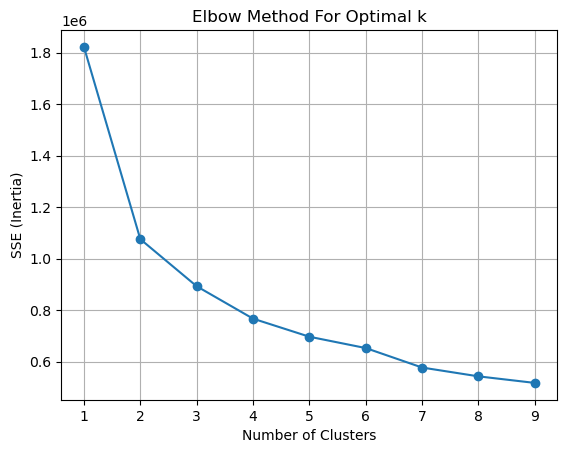

In [92]:
sse = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    sse.append(km.inertia_)

# Plot
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

# Step 5: Train Supervised Models to Predict Risk Category

In [93]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, clusters, test_size=0.2, random_state=42, stratify=clusters
)

# Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluate
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nConfusion Matrix (KNN):\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report (KNN):\n", classification_report(y_test, y_pred_knn))

# Train Decision Tree
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

# Predict
y_pred_tree = tree.predict(X_test)

# Evaluate
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nConfusion Matrix (Tree):\n", confusion_matrix(y_test, y_pred_tree))
print("\nClassification Report (Tree):\n", classification_report(y_test, y_pred_tree))

KNN Accuracy: 0.9802192917469255

Confusion Matrix (KNN):
 [[ 9179    51    70    82]
 [   72  7021     0    97]
 [   63     0 15317    64]
 [  127    77    98  8176]]

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      9382
           1       0.98      0.98      0.98      7190
           2       0.99      0.99      0.99     15444
           3       0.97      0.96      0.97      8478

    accuracy                           0.98     40494
   macro avg       0.98      0.98      0.98     40494
weighted avg       0.98      0.98      0.98     40494

Decision Tree Accuracy: 0.9045290660344742

Confusion Matrix (Tree):
 [[ 8696   230   320   136]
 [  643  5951     0   596]
 [  284     0 14720   440]
 [  516   246   455  7261]]

Classification Report (Tree):
               precision    recall  f1-score   support

           0       0.86      0.93      0.89      9382
           1       0.93      0.83      0.87   

# Step 6: Save Trained Models

In [94]:
joblib.dump(knn, 'models/knn_model.pkl')
joblib.dump(tree, 'models/decision_tree_model.pkl')
joblib.dump(kmeans, 'models/kmeans_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

['models/scaler.pkl']

# Step 7: Visualize Risk Groups using PCA

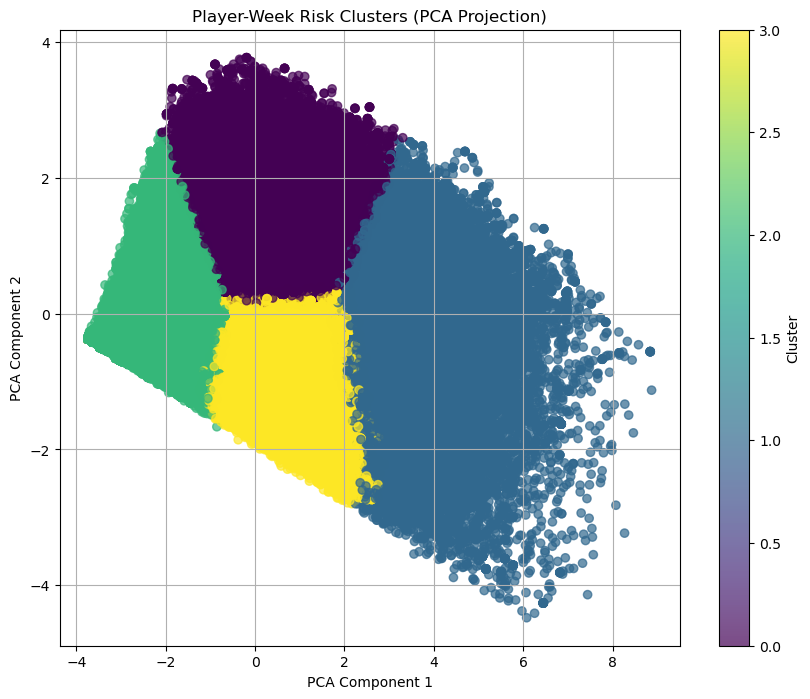

In [95]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Player-Week Risk Clusters (PCA Projection)')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

# Step 8: Map Cluster IDs to Risk Levels

In [99]:
# Group player weeks by their assigned cluster
cluster_profile = player_week_data.loc[X.index].copy()
cluster_profile['risk_cluster'] = clusters

# Summarize key features
cluster_summary = cluster_profile.groupby('risk_cluster').agg({
    'injury_count': 'mean',
    'avg_minutes': 'mean',
    'back_to_back_games': 'mean',
    'games_played': 'mean'
}).reset_index()

# Display
cluster_summary


,risk_cluster,injury_count,avg_minutes,back_to_back_games,games_played
0,0,5.944000,18.791062,28.605530,60.391465
1,1,9.376485,31.157261,22.346778,53.872354
2,2,1.888696,9.143501,6.411015,11.137890
3,3,6.536249,22.609877,6.855404,17.578338


In [100]:
risk_mapping = {
    2: 'Low Risk',
    3: 'Medium Risk',
    0: 'High Risk',
    1: 'Very High Risk'
}

X_with_clusters['risk_level'] = X_with_clusters['risk_cluster'].map(risk_mapping)
X_with_clusters[['risk_cluster', 'risk_level']].head()


,risk_cluster,risk_level
0,2,Low Risk
1,3,Medium Risk
2,2,Low Risk
3,3,Medium Risk
4,2,Low Risk


# Step 9: Save Risk Mapping for Use in Web App

In [101]:
import json

with open('models/risk_mapping.json', 'w') as f:
    json.dump(risk_mapping, f)

# Step 10: Bonus — 3D PCA Visualization of Risk Clusters

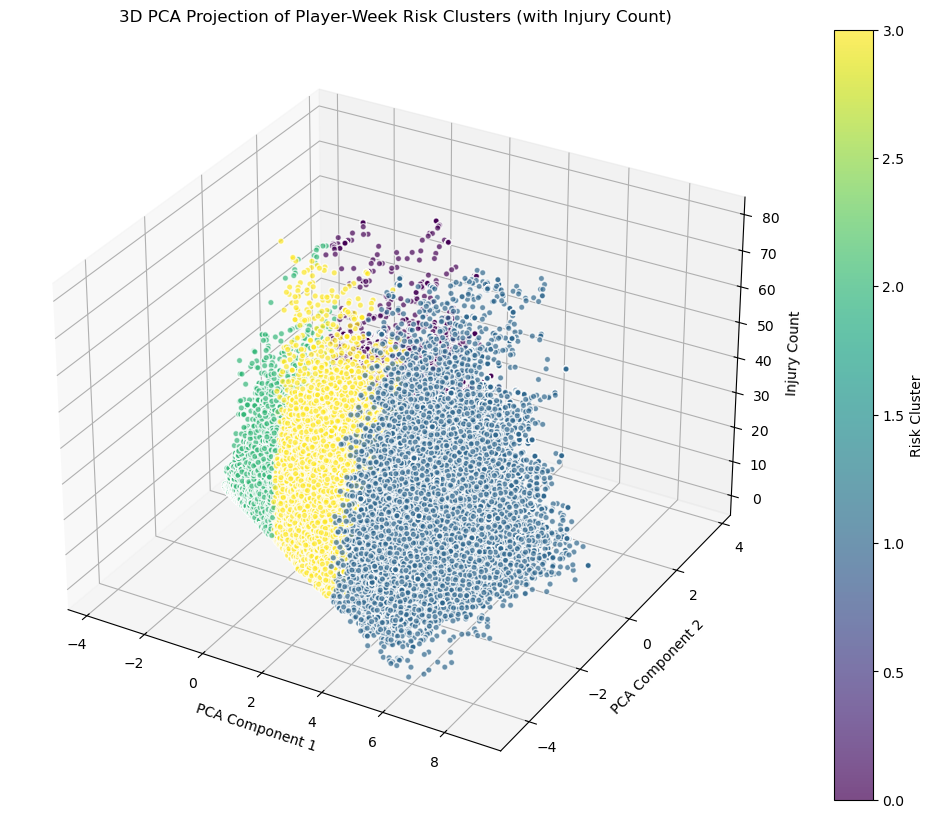

In [102]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Step 1: PCA with 2 components (X and Y)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 2: Real injury counts for Z-axis
injury_count = data.loc[X.index, 'injury_count'].values  # match rows

# Step 3: 3D Plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],            # PCA Component 1 (X-axis)
    X_pca[:, 1],            # PCA Component 2 (Y-axis)
    injury_count,           # Real Injury Count (Z-axis)
    c=clusters,             # Color by risk cluster
    cmap='viridis',         
    alpha=0.7,
    edgecolors='w'
)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('Injury Count')
ax.set_title('3D PCA Projection of Player-Week Risk Clusters (with Injury Count)')

fig.colorbar(scatter, ax=ax, label='Risk Cluster')
plt.show()
